Part A

In [12]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')


start_date = '1960-01-01'
end_date = '2025-12-31'

tickers = ['FEDFUNDS', 'CPIAUCSL', 'UNRATE']
df = web.DataReader(tickers, 'fred', start_date, end_date)

df_quarterly = df.resample('QS').mean()

df_quarterly['INFLATION'] = 400 * np.log(df_quarterly['CPIAUCSL'] / df_quarterly['CPIAUCSL'].shift(1))

df_quarterly = df_quarterly.dropna()

df_quarterly = df_quarterly.rename(columns={'FEDFUNDS': 'INTEREST_RATE', 'UNRATE': 'UNEMPLOYMENT'})

print("Data shape after processing:", df_quarterly.shape)
display(df_quarterly.head())
display(df_quarterly.tail())

Data shape after processing: (263, 4)


,INTEREST_RATE,CPIAUCSL,UNEMPLOYMENT,INFLATION
DATE,,,,
1960-04-01,3.696667,29.573333,5.233333,2.396706
1960-07-01,2.936667,29.590000,5.533333,0.225365
1960-10-01,2.296667,29.780000,6.266667,2.560224
1961-01-01,2.003333,29.840000,6.800000,0.805099
1961-04-01,1.733333,29.830000,7.000000,-0.134071


,INTEREST_RATE,CPIAUCSL,UNEMPLOYMENT,INFLATION
DATE,,,,
2024-10-01,4.650000,316.587667,4.133333,3.128772
2025-01-01,4.330000,319.475000,4.133333,3.631533
2025-04-01,4.330000,320.785667,4.200000,1.637669
2025-07-01,4.293333,323.235000,4.333333,3.042567
2025-10-01,3.896667,325.547000,4.450000,2.850893


Part B

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 20, Apr, 2026
Time:                     21:09:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   0.498185
Nobs:                     259.000    HQIC:                  0.177937
Log likelihood:          -1058.67    FPE:                   0.963535
AIC:                   -0.0373993    Det(Omega_mle):        0.831879
--------------------------------------------------------------------
Results for equation INTEREST_RATE
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.126529         0.205098            0.617           0.537
L1.INTEREST_RATE         1.269487         0.067444           18.823           0.000
L1.INFLATION            -0.027528       

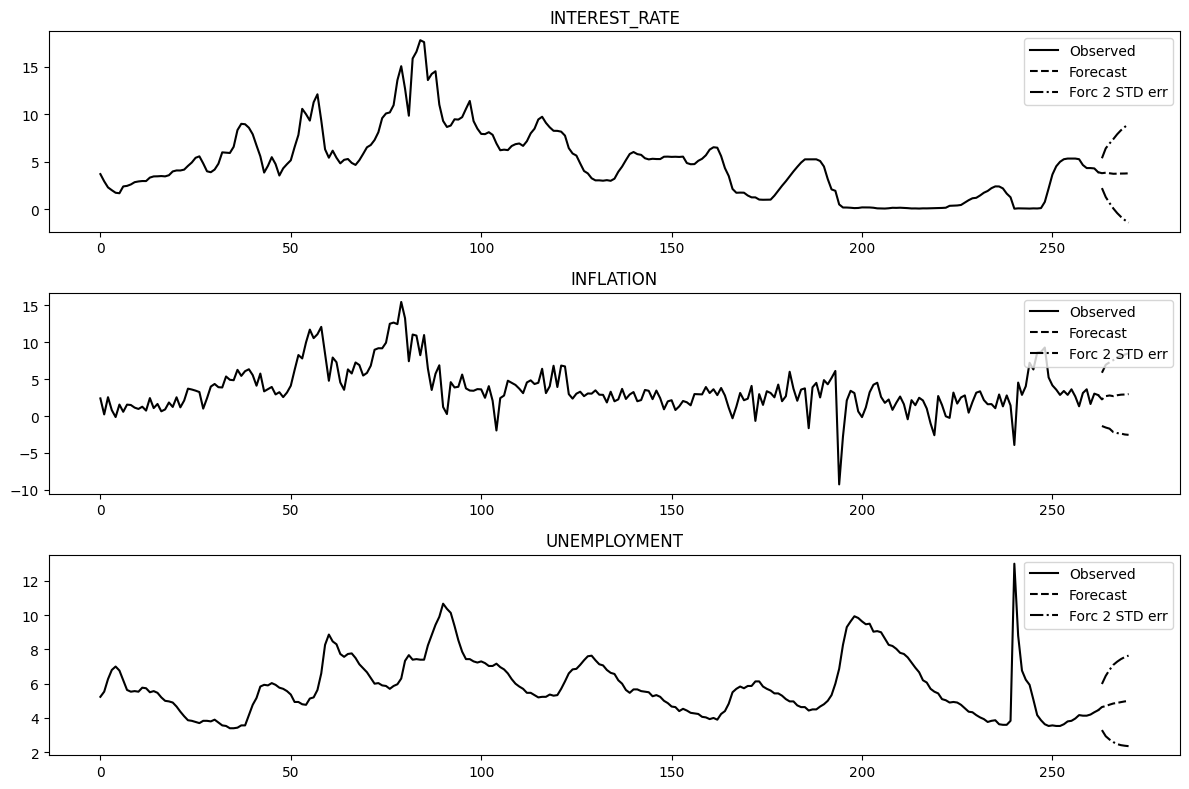

In [15]:
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt


data = df_quarterly[['INTEREST_RATE', 'INFLATION', 'UNEMPLOYMENT']]

model = VAR(data)
results = model.fit(4)

print(results.summary())

forecast_steps = 8
forecast = results.forecast(data.values[-results.k_ar:], steps=forecast_steps)

fig = results.plot_forecast(forecast_steps)
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Part C

In [16]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

train_data = df_quarterly.loc[:'2023-12-31', ['INTEREST_RATE', 'INFLATION', 'UNEMPLOYMENT']]

test_data = df_quarterly.loc['2024-01-01':'2025-12-31', ['INTEREST_RATE', 'INFLATION', 'UNEMPLOYMENT']]

model_c = VAR(train_data)
results_c = model_c.fit(4)

forecast_steps = 8
forecast_c = results_c.forecast(train_data.values[-results_c.k_ar:], steps=forecast_steps)

forecast_df = pd.DataFrame(forecast_c, index=test_data.index[:forecast_steps], columns=train_data.columns)

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Mean Absolute Percentage Errors (MAPE) for 8-quarter ahead forecasts:")
for col in train_data.columns:
    actual = test_data[col].values[:forecast_steps]
    pred = forecast_df[col].values
    mape_val = calculate_mape(actual, pred)
    print(f"{col}: {mape_val:.2f}%")


Mean Absolute Percentage Errors (MAPE) for 8-quarter ahead forecasts:
INTEREST_RATE: 9.52%
INFLATION: 37.77%
UNEMPLOYMENT: 8.41%


Part D

In [17]:
import numpy as np
import pandas as pd

print("Mean Absolute Percentage Errors (MAPE) for Naive Forecasts (8-quarter ahead):")
for col in train_data.columns:
    actual = test_data[col].values[:forecast_steps]
    last_observed_value = train_data[col].iloc[-1]
    pred = np.repeat(last_observed_value, forecast_steps)

    mape_val = calculate_mape(actual, pred)
    print(f"{col}: {mape_val:.2f}%")


Mean Absolute Percentage Errors (MAPE) for Naive Forecasts (8-quarter ahead):
INTEREST_RATE: 15.38%
INFLATION: 32.01%
UNEMPLOYMENT: 8.30%


Part E

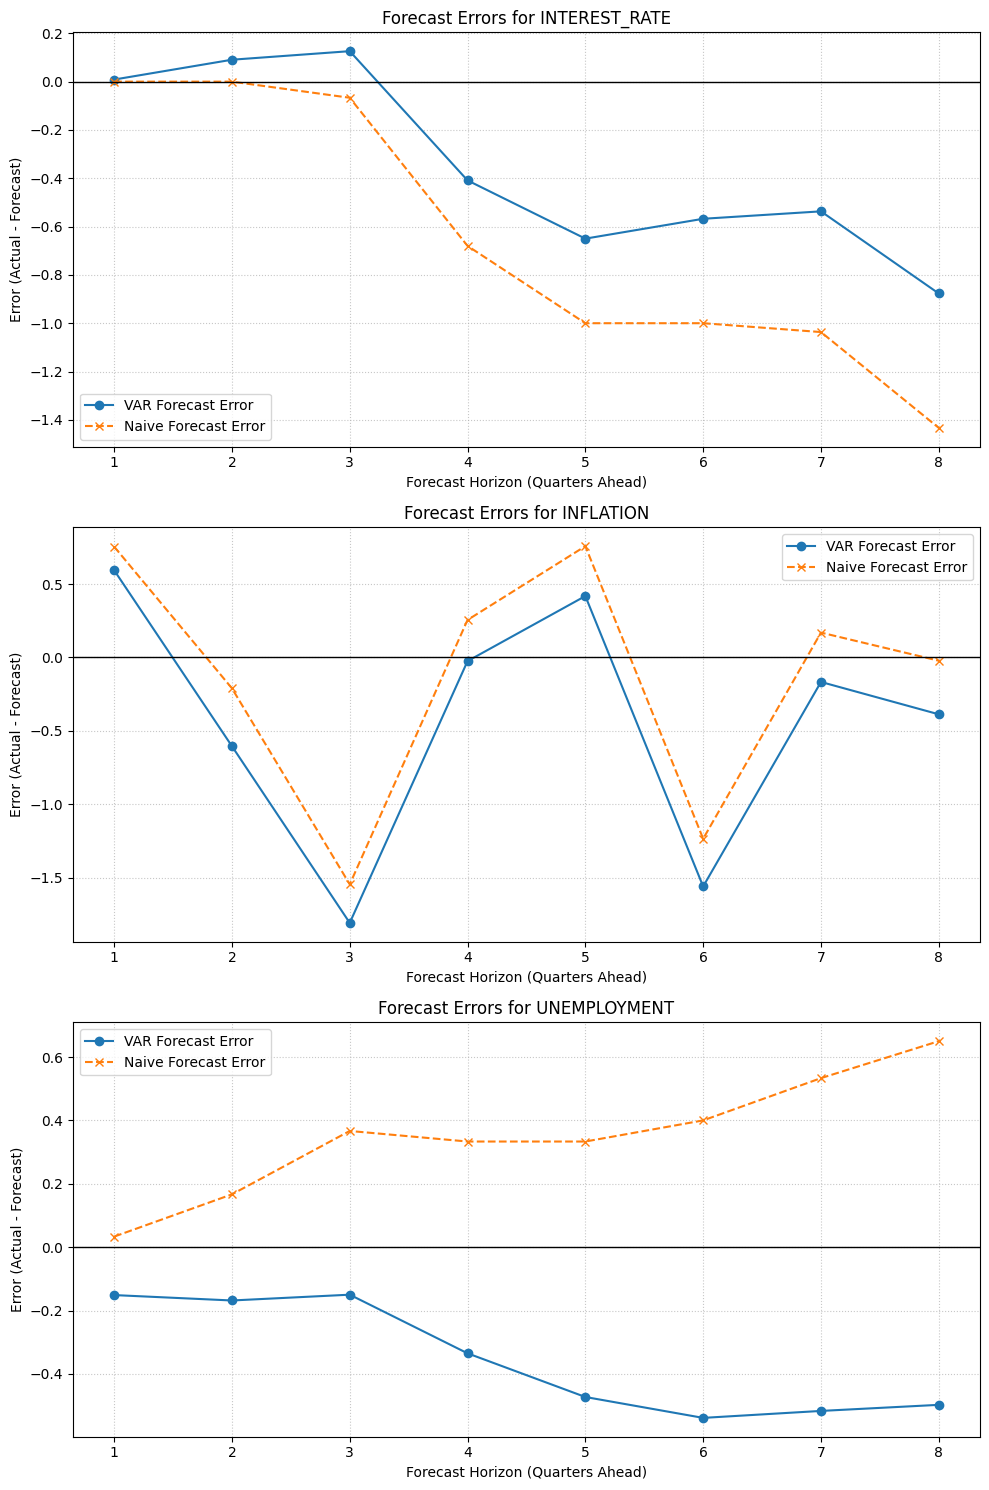

In [5]:
import matplotlib.pyplot as plt

horizons = np.arange(1, forecast_steps + 1)


fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, col in enumerate(train_data.columns):
    actual = test_data[col].values[:forecast_steps]

    var_pred = forecast_df[col].values
    var_errors = actual - var_pred

    last_observed = train_data[col].iloc[-1]
    naive_pred = np.repeat(last_observed, forecast_steps)
    naive_errors = actual - naive_pred

    axes[i].plot(horizons, var_errors, label='VAR Forecast Error', marker='o')
    axes[i].plot(horizons, naive_errors, label='Naive Forecast Error', marker='x', linestyle='--')
    axes[i].set_title(f'Forecast Errors for {col}')
    axes[i].set_xlabel('Forecast Horizon (Quarters Ahead)')
    axes[i].set_ylabel('Error (Actual - Forecast)')
    axes[i].axhline(0, color='black', linewidth=1, linestyle='-')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


Part F

In [19]:
import pandas as pd

variables = ['INTEREST_RATE', 'INFLATION', 'UNEMPLOYMENT']
causality_data = []

print("Granger Causality Test Results (F-tests):\n")

for caused in variables:
    for causing in variables:
        if caused != causing:
            res = results.test_causality(caused, causing, kind='f')
            p_val = res.pvalue

            causality_data.append({
                'Caused Variable': caused,
                'Causing Variable': causing,
                'p-value': p_val,
                'Granger Causes (at 5%)': p_val < 0.05
            })


causality_df = pd.DataFrame(causality_data)
display(causality_df)


Granger Causality Test Results (F-tests):



,Caused Variable,Causing Variable,p-value,Granger Causes (at 5%)
0,INTEREST_RATE,INFLATION,0.036391,True
1,INTEREST_RATE,UNEMPLOYMENT,0.420606,False
2,INFLATION,INTEREST_RATE,0.000714,True
3,INFLATION,UNEMPLOYMENT,0.288603,False
4,UNEMPLOYMENT,INTEREST_RATE,0.046154,True
5,UNEMPLOYMENT,INFLATION,0.282648,False


Part G

In [20]:
import numpy as np
import pandas as pd

struct_order = ['INFLATION', 'UNEMPLOYMENT', 'INTEREST_RATE']

sigma_u = results.sigma_u.loc[struct_order, struct_order]

L = np.linalg.cholesky(sigma_u)

D_inv = np.diag(1 / np.diag(L))
B = L @ D_inv

B_inv = np.linalg.inv(B)

print("Variables ordering:", struct_order)
print("\nMatrix B (Lower triangular with 1s on diagonal):")
print(pd.DataFrame(B, index=struct_order, columns=struct_order))

print("\nMatrix B_inv (Inverse of B):")
print(pd.DataFrame(B_inv, index=struct_order, columns=struct_order))

Variables ordering: ['INFLATION', 'UNEMPLOYMENT', 'INTEREST_RATE']

Matrix B (Lower triangular with 1s on diagonal):
               INFLATION  UNEMPLOYMENT  INTEREST_RATE
INFLATION       1.000000       0.00000            0.0
UNEMPLOYMENT   -0.099763       1.00000            0.0
INTEREST_RATE   0.115915      -0.28216            1.0

Matrix B_inv (Inverse of B):
               INFLATION  UNEMPLOYMENT  INTEREST_RATE
INFLATION       1.000000       0.00000            0.0
UNEMPLOYMENT    0.099763       1.00000            0.0
INTEREST_RATE  -0.087766       0.28216            1.0


Part H

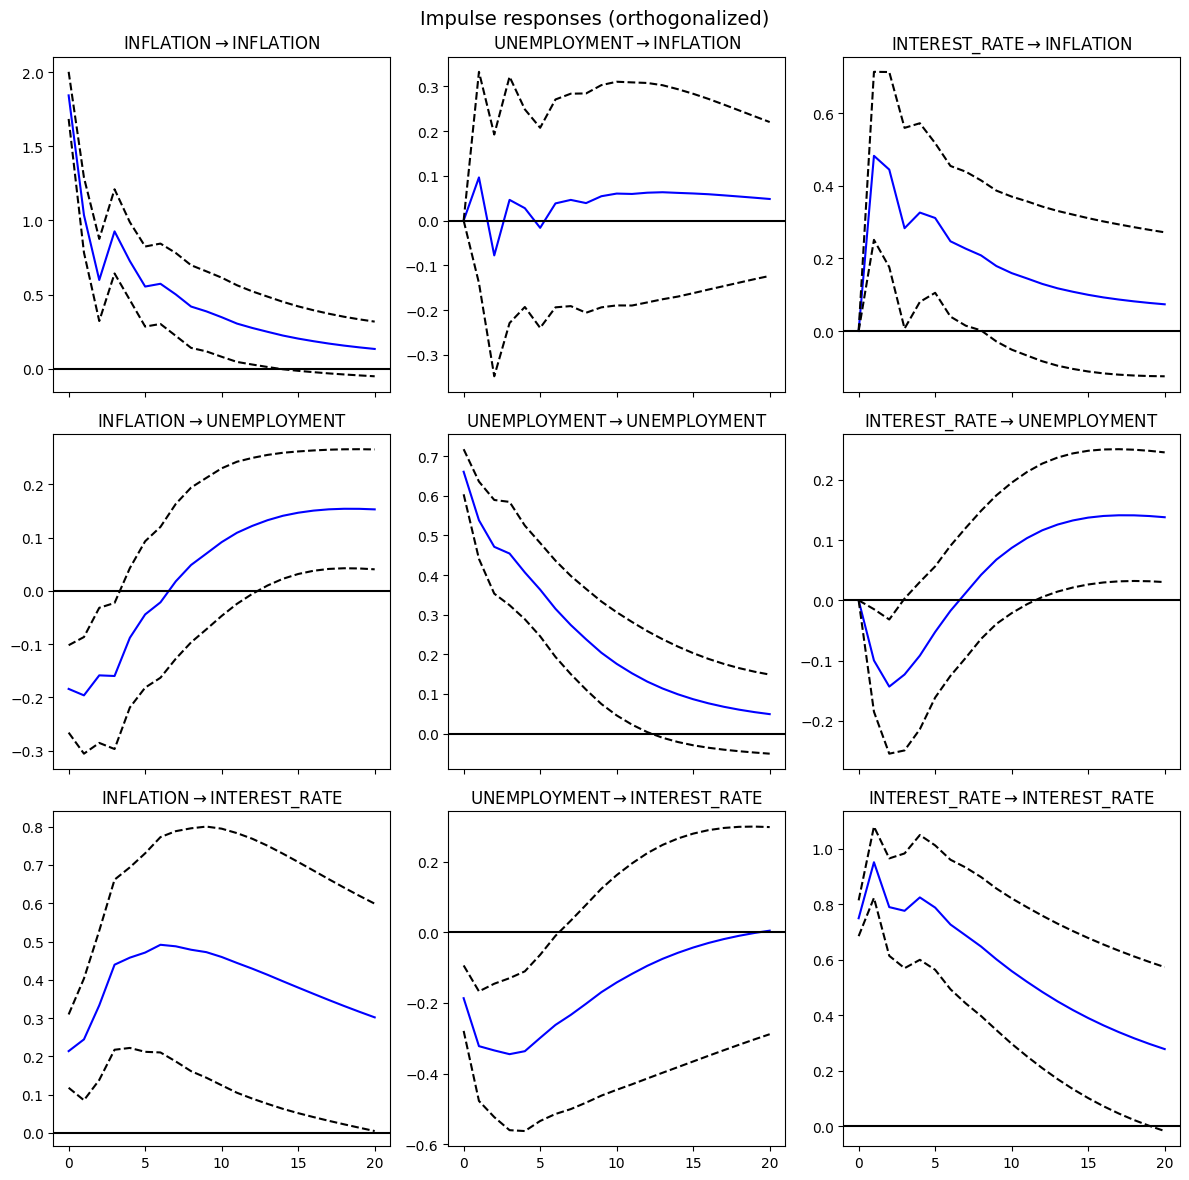

In [21]:
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

data_struct = df_quarterly[['INFLATION', 'UNEMPLOYMENT', 'INTEREST_RATE']]
model_struct = VAR(data_struct)
results_struct = model_struct.fit(4)

irf = results_struct.irf(20)

fig = irf.plot(orth=True)
fig.set_size_inches(12, 12)
plt.tight_layout()
plt.show()

Part I

Forecast Error Variance Decomposition for INFLATION:


,Shock to INFLATION,Shock to UNEMPLOYMENT,Shock to INTEREST_RATE (Monetary Policy)
Horizon 1,1.000000,0.000000,0.000000
Horizon 2,0.948545,0.001967,0.049488
Horizon 3,0.915339,0.002908,0.081753
Horizon 4,0.914885,0.002811,0.082304


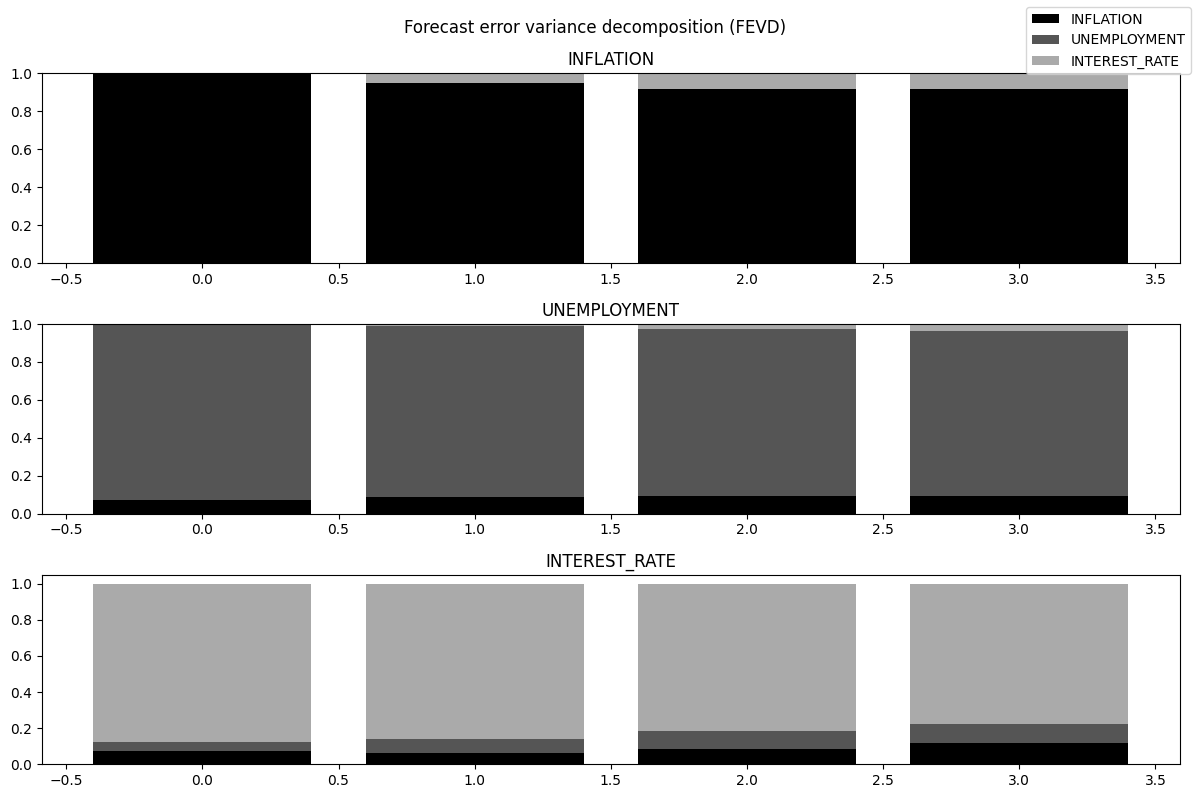

In [22]:
import pandas as pd

fevd = results_struct.fevd(4)

inflation_fevd = fevd.decomp[0, :, :]

df_fevd_inflation = pd.DataFrame(
    inflation_fevd,
    columns=['Shock to INFLATION', 'Shock to UNEMPLOYMENT', 'Shock to INTEREST_RATE (Monetary Policy)'],
    index=[f'Horizon {h}' for h in range(1, 5)]
)

print("Forecast Error Variance Decomposition for INFLATION:")
display(df_fevd_inflation)

fig = fevd.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()